
---LOADING ADULT DATASET---

Dataset shape: (48842, 14)

---CALCULATING FOLD F1 SCORES---

Logistic Regression: 0.6744 ± 0.0049
Random Forest: 0.6683 ± 0.0059
Gradient Boosting: 0.7120 ± 0.0053

---TOP 2 MODELS---

1. Gradient Boosting
2. Logistic Regression


---STATISTICAL COMPARISON---


Paired t-test:
t-statistic = 41.6646
p-value = 0.0000

Wilcoxon signed-rank test:
Statistic = 0.0000
p-value = 0.0625

---STATISTICAL INTERPRETATION---

Paired t-test: statistically significant difference between the top two models (p < 0.05).
Wilcoxon test: no statistically significant difference (p >= 0.05).

PRACTICAL DIFFERENCE
Gradient Boosting mean F1: 0.7120
Logistic Regression mean F1: 0.6744
F1 difference: 0.0376

---TOP 20 LOGISTIC REGRESSION FEATURES---

                                       Feature  Coefficient  Absolute_Coefficient
                     numeric__log_capital_gain     6.217457              6.217457
                    numeric__capital_gain_flag    -5.898355              

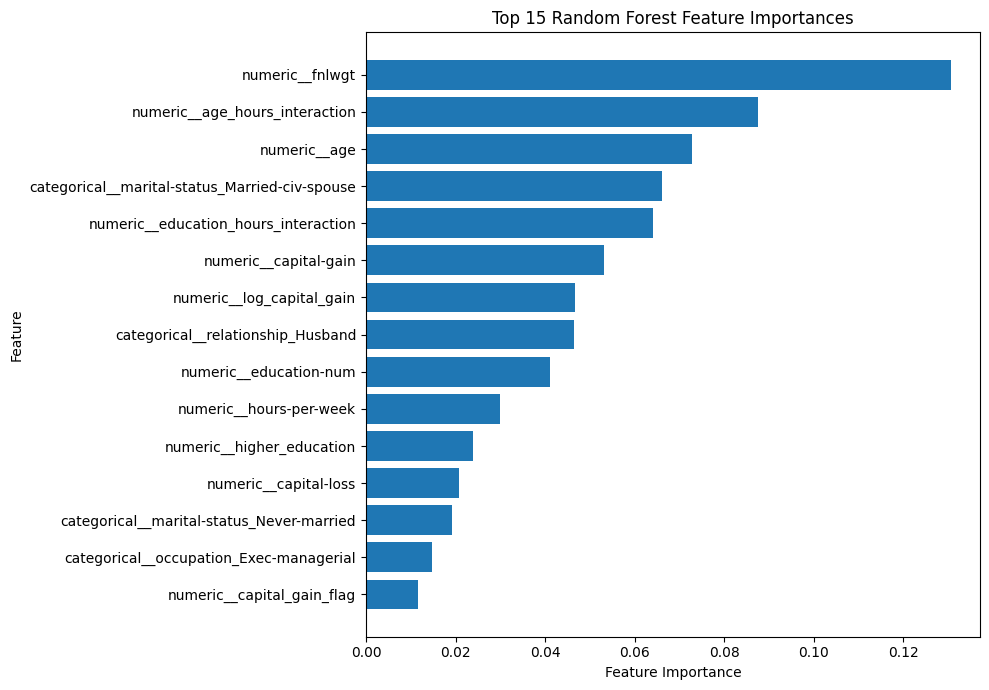

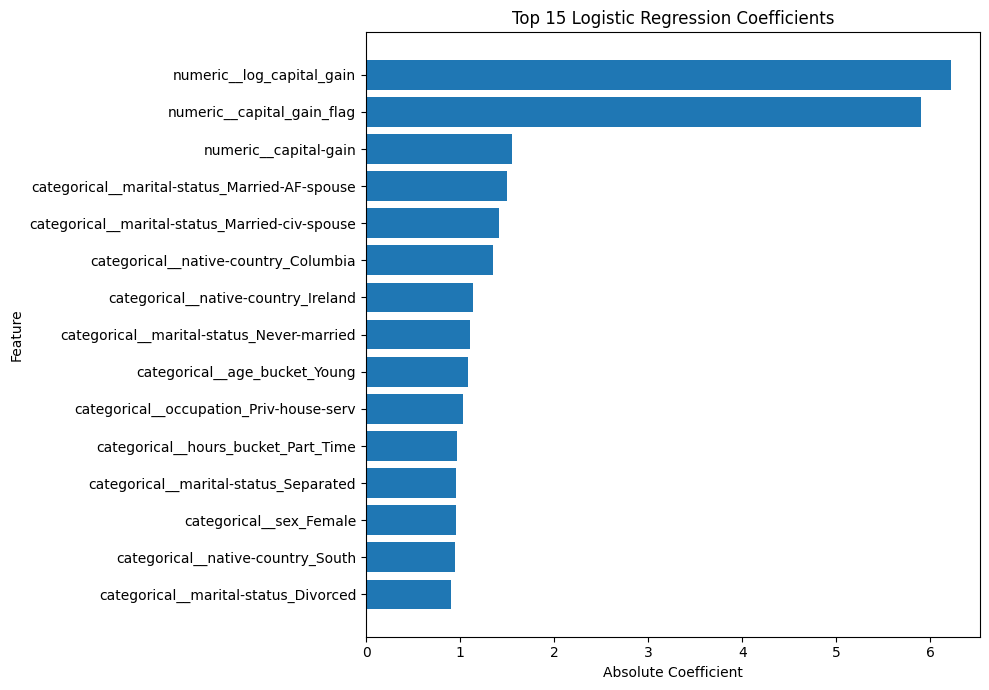

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import f1_score
from sklearn.base import clone

from scipy.stats import ttest_rel, wilcoxon


os.makedirs("../outputs", exist_ok=True)


print("\n---LOADING ADULT DATASET---\n")

adult = fetch_openml(
    "adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

df = df.replace("?", np.nan)

df["target"] = df["class"].map({
    "<=50K": 0,
    ">50K": 1
}).astype(int)

X = df.drop(columns=["class", "target"])
y = df["target"]

print("Dataset shape:", X.shape)


def create_engineered_features(data):

    data = data.copy()

    data["age_bucket"] = pd.cut(
        data["age"],
        bins=[0, 25, 35, 45, 55, 65, np.inf],
        labels=[
            "Young",
            "Early_Career",
            "Mid_Career",
            "Experienced",
            "Senior",
            "Older"
        ],
        include_lowest=True
    )

    data["hours_bucket"] = pd.cut(
        data["hours-per-week"],
        bins=[0, 30, 40, 50, 60, np.inf],
        labels=[
            "Part_Time",
            "Standard",
            "Overtime",
            "High_Hours",
            "Very_High_Hours"
        ],
        include_lowest=True
    )

    data["capital_gain_flag"] = (
        data["capital-gain"] > 0
    ).astype(int)

    data["log_capital_gain"] = np.log1p(
        data["capital-gain"]
    )

    data["higher_education"] = (
        data["education-num"] >= 13
    ).astype(int)

    data["education_hours_interaction"] = (
        data["education-num"]
        * data["hours-per-week"]
    )

    data["capital_loss_flag"] = (
        data["capital-loss"] > 0
    ).astype(int)

    data["age_hours_interaction"] = (
        data["age"]
        * data["hours-per-week"]
    )

    return data


feature_engineering = FunctionTransformer(
    create_engineered_features,
    validate=False
)


numeric_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",

    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "education_hours_interaction",
    "capital_loss_flag",
    "age_hours_interaction"
]

categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",

    "age_bucket",
    "hours_bucket"
]


numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


models = {

    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        random_state=42
    )
}
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
fold_scores = {}
print("\n---CALCULATING FOLD F1 SCORES---\n")
for model_name, model in models.items():

    scores = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[test_idx]

        pipeline = Pipeline([
            (
                "feature_engineering",
                clone(feature_engineering)
            ),
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                clone(model)
            )
        ])

        pipeline.fit(
            X_train,
            y_train
        )

        predictions = pipeline.predict(
            X_valid
        )

        score = f1_score(
            y_valid,
            predictions
        )

        scores.append(score)

    fold_scores[model_name] = np.array(scores)

    print(
        f"{model_name}: "
        f"{np.mean(scores):.4f} ± {np.std(scores):.4f}"
    )


model_means = {
    name: np.mean(scores)
    for name, scores in fold_scores.items()
}

sorted_models = sorted(
    model_means,
    key=model_means.get,
    reverse=True
)
top_model_1 = sorted_models[0]
top_model_2 = sorted_models[1]

scores_1 = fold_scores[top_model_1]
scores_2 = fold_scores[top_model_2]
print("\n---TOP 2 MODELS---\n")

print("1.", top_model_1)
print("2.", top_model_2)


t_stat, t_pvalue = ttest_rel(
    scores_1,
    scores_2
)


try:

    w_stat, w_pvalue = wilcoxon(
        scores_1,
        scores_2
    )

except ValueError:

    w_stat = np.nan
    w_pvalue = np.nan
print("\n---STATISTICAL COMPARISON---\n")

print(
    f"\nPaired t-test:"
)

print(
    f"t-statistic = {t_stat:.4f}"
)

print(
    f"p-value = {t_pvalue:.4f}"
)

print(
    f"\nWilcoxon signed-rank test:"
)

print(
    f"Statistic = {w_stat:.4f}"
)

print(
    f"p-value = {w_pvalue:.4f}"
)
alpha = 0.05
print("\n---STATISTICAL INTERPRETATION---\n")

if t_pvalue < alpha:

    print(
        "Paired t-test: statistically significant difference "
        "between the top two models (p < 0.05)."
    )

else:

    print(
        "Paired t-test: no statistically significant difference "
        "between the top two models (p >= 0.05)."
    )


if not np.isnan(w_pvalue):

    if w_pvalue < alpha:

        print(
            "Wilcoxon test: statistically significant difference "
            "(p < 0.05)."
        )

    else:

        print(
            "Wilcoxon test: no statistically significant difference "
            "(p >= 0.05)."
        )


mean_difference = (
    np.mean(scores_1) -
    np.mean(scores_2)
)

print("\n---PRACTICAL DIFFERENCE---\n")

print(
    f"{top_model_1} mean F1: "
    f"{np.mean(scores_1):.4f}"
)

print(
    f"{top_model_2} mean F1: "
    f"{np.mean(scores_2):.4f}"
)

print(
    f"F1 difference: "
    f"{mean_difference:.4f}"
)


trained_pipelines = {}

for model_name in [
    "Logistic Regression",
    "Random Forest"
]:

    pipeline = Pipeline([
        (
            "feature_engineering",
            feature_engineering
        ),
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            models[model_name]
        )
    ])

    pipeline.fit(
        X,
        y
    )

    trained_pipelines[model_name] = pipeline


logistic_pipeline = trained_pipelines[
    "Logistic Regression"
]

rf_pipeline = trained_pipelines[
    "Random Forest"
]

feature_names = (
    logistic_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


logistic_model = (
    logistic_pipeline
    .named_steps["classifier"]
)

coefficients = logistic_model.coef_[0]

logistic_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

logistic_importance = (
    logistic_importance
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)
print("\n---TOP 20 LOGISTIC REGRESSION FEATURES---\n")
print(
    logistic_importance
    .head(20)
    .to_string(index=False)
)


rf_model = (
    rf_pipeline
    .named_steps["classifier"]
)

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)
print("\n---TOP 20 RANDOM FOREST FEATURES---\n")

print(
    rf_importance
    .head(20)
    .to_string(index=False)
)


engineered_keywords = [
    "age_bucket",
    "hours_bucket",
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "education_hours_interaction",
    "capital_loss_flag",
    "age_hours_interaction"
]

logistic_engineered = logistic_importance[
    logistic_importance["Feature"].apply(
        lambda x: any(
            keyword in x
            for keyword in engineered_keywords
        )
    )
].copy()


rf_engineered = rf_importance[
    rf_importance["Feature"].apply(
        lambda x: any(
            keyword in x
            for keyword in engineered_keywords
        )
    )
].copy()
print("\n---ENGINEERED FEATURES - LOGISTIC REGRESSION---\n")
print(
    logistic_engineered.to_string(index=False)
)

print("\n---ENGINEERED FEATURES - RANDOM FOREST---\n")

print(
    rf_engineered.to_string(index=False)
)
statistical_results = pd.DataFrame({
    "Top Model": [top_model_1],
    "Second Model": [top_model_2],
    "Top Model Mean F1": [np.mean(scores_1)],
    "Second Model Mean F1": [np.mean(scores_2)],
    "F1 Difference": [mean_difference],
    "Paired T Statistic": [t_stat],
    "Paired T P Value": [t_pvalue],
    "Wilcoxon Statistic": [w_stat],
    "Wilcoxon P Value": [w_pvalue]
})

statistical_results.to_csv(
    "../outputs/day3_task4_statistical_test.csv",
    index=False
)

logistic_importance.to_csv(
    "../outputs/day3_task4_logistic_feature_importance.csv",
    index=False
)

rf_importance.to_csv(
    "../outputs/day3_task4_random_forest_feature_importance.csv",
    index=False
)

logistic_engineered.to_csv(
    "../outputs/day3_task4_logistic_engineered_features.csv",
    index=False
)

rf_engineered.to_csv(
    "../outputs/day3_task4_rf_engineered_features.csv",
    index=False
)


top_rf = rf_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.tight_layout()

plt.savefig(
    "../outputs/day3_task4_random_forest_importance.png",
    dpi=300
)

plt.show()


top_logistic = logistic_importance.head(15).sort_values(
    "Absolute_Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_logistic["Feature"],
    top_logistic["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title(
    "Top 15 Logistic Regression Coefficients"
)

plt.tight_layout()

plt.savefig(
    "../outputs/day3_task4_logistic_coefficients.png",
    dpi=300
)

plt.show()


